In [1]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
#step-1.Import required libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix,accuracy_score 
from sklearn.metrics import classification_report
from sklearn import tree


In [3]:
#step-2.import required dataset:

data=pd.read_csv(r"C:\Users\ELCOT\Downloads\cancer_dataset.csv")
data.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,diagnosis
0,13.745401,10.628584,114.203165,362.018065,0.060312,B
1,19.507143,22.728208,58.413996,937.625558,0.140255,M
2,17.319939,16.287120,66.162871,948.762146,0.100525,M
3,15.986585,20.171414,139.855419,1064.915882,0.132646,M
4,11.560186,28.151329,110.642906,1171.309600,0.082005,M


In [4]:
#step-3.preprocessing:

data.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   radius_mean      100 non-null    float64
 1   texture_mean     100 non-null    float64
 2   perimeter_mean   100 non-null    float64
 3   area_mean        100 non-null    float64
 4   smoothness_mean  100 non-null    float64
 5   diagnosis        100 non-null    str    
dtypes: float64(5), str(1)
memory usage: 4.8 KB


In [5]:
#step-4.Assing dependent and independent variable:

x=data.iloc[:,:-1].values
y=data.iloc[:,-1].values

In [6]:
#step-5.Split the data into training and testing:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=41)
display(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(70, 5)

(70,)

(30, 5)

(30,)

In [7]:
#step-6.Preprocessing data with StandardScaler:

sc=StandardScaler()

x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [8]:
#step-7.Fitting the model random forest classifier:

model=RandomForestClassifier(criterion="entropy",random_state=5)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [9]:
#step-8.Compute and visualize:

y_pred=model.predict(x_test)
print('y_pred:',y_pred)

y_pred: ['M' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'B' 'M' 'M' 'M' 'M' 'M' 'B' 'B'
 'B' 'M' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B' 'B']


In [10]:
#step-9.Evaluation matrix:

print('Random Forest Classifier')
conf_mat=metrics.confusion_matrix(y_test,y_pred)
print('\n confusion matrix: \n',conf_mat)
Accuracy_score=accuracy_score(y_test,y_pred)
print('Accuracy score: ',Accuracy_score)
print('Accuracy in percentage:', int(Accuracy_score * 100), '%')
print('\n',classification_report(y_pred,y_test))



Random Forest Classifier

 confusion matrix: 
 [[6 6]
 [9 9]]
Accuracy score:  0.5
Accuracy in percentage: 50 %

               precision    recall  f1-score   support

           B       0.50      0.40      0.44        15
           M       0.50      0.60      0.55        15

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.49        30
weighted avg       0.50      0.50      0.49        30



[Text(0.5, 1.0, 'Random Forest Classifier')]

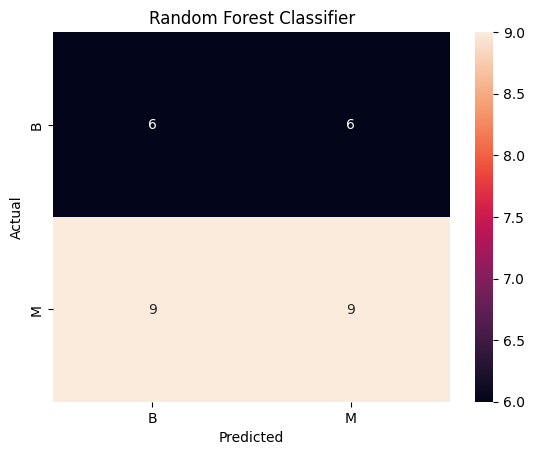

In [11]:
#plotting:

conf_mat=pd.crosstab(y_test,y_pred, rownames=['Actual'],colnames=['Predicted'])
sn.heatmap(conf_mat,annot=True).set(title='Random Forest Classifier')

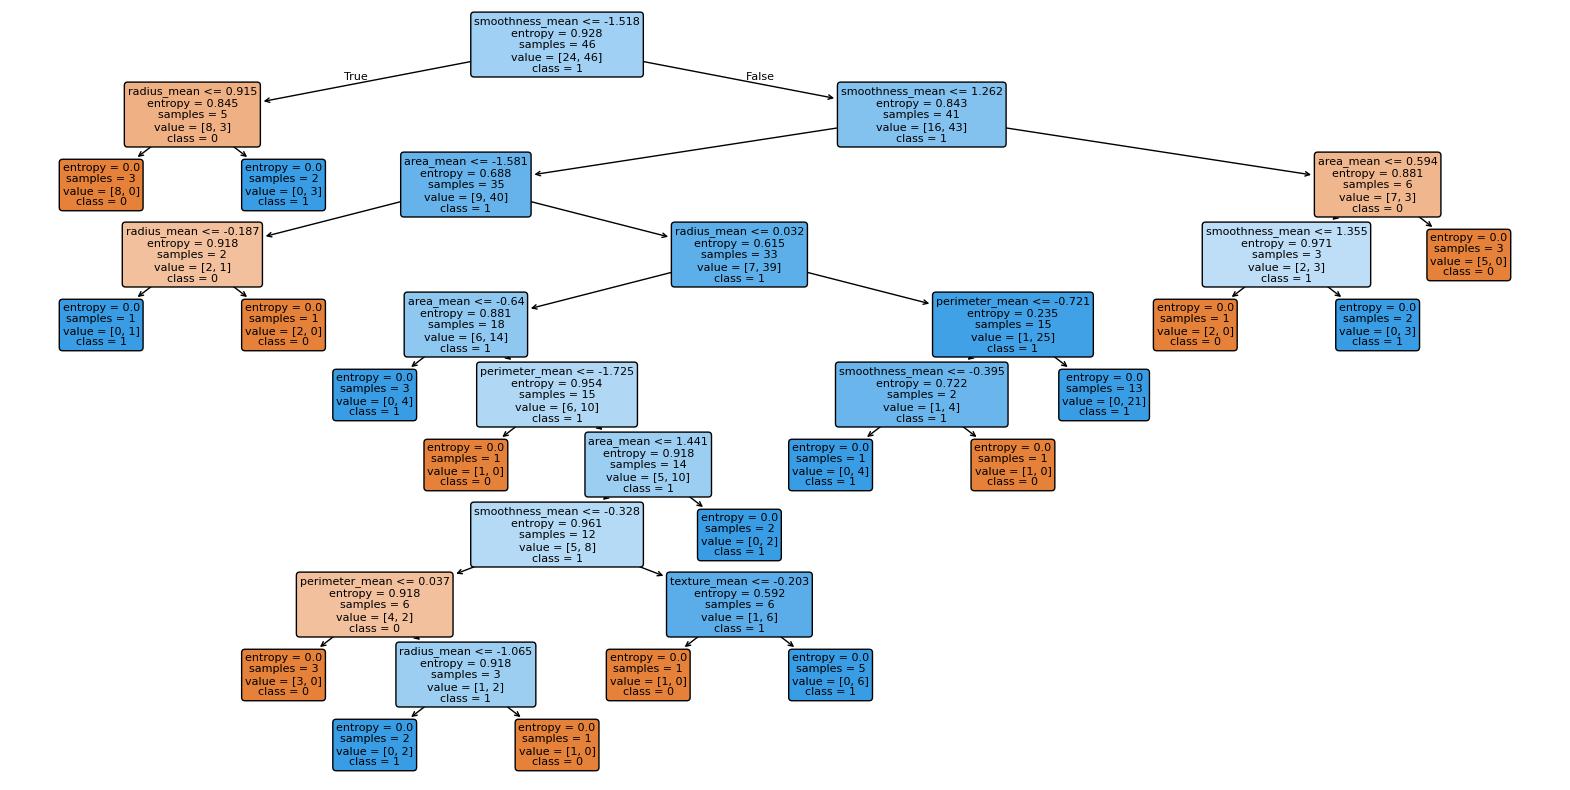

In [12]:
#step-10.visualizing tree formed:

plt.figure(figsize=(20,10))
tree.plot_tree(
    model.estimators_[0],
    feature_names=list(data.columns[:-1]),
    class_names=['0','1'],
    filled=True,
    rounded=True,
    fontsize=8  
    )
plt.savefig('tree.png', dpi=300, bbox_inches='tight')
plt.show()